# E-commerce Funnel Drop-off Analysis

## Objective
Analyze user behavior across the funnel (view → cart → purchase) to identify drop-off points and optimization opportunities.

In [2]:
import pandas as pd
df = pd.read_csv("2019-Dec.csv", nrows=100000)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [3]:
df["event_type"].value_counts()

event_type
view                46007
cart                26771
remove_from_cart    21350
purchase             5872
Name: count, dtype: int64

In [3]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("ecommerce.db")
df.to_sql("events", conn, if_exists="replace", index=False)

100000

In [6]:
query = """
SELECT 
    event_type,
    COUNT(DISTINCT user_id) as users
FROM events
GROUP BY event_type
"""

pd.read_sql(query, conn)

,event_type,users
0,cart,3315
1,purchase,644
2,remove_from_cart,1973
3,view,13382


In [4]:
query = """
SELECT 
    event_type,
    COUNT(DISTINCT user_id) as users
FROM events
GROUP BY event_type
"""

funnel = pd.read_sql(query, conn)
funnel

,event_type,users
0,cart,3315
1,purchase,644
2,remove_from_cart,1973
3,view,13382


In [5]:
view_users = funnel[funnel["event_type"]=="view"]["users"].values[0]
cart_users = funnel[funnel["event_type"]=="cart"]["users"].values[0]
purchase_users = funnel[funnel["event_type"]=="purchase"]["users"].values[0]
view_to_cart = cart_users / view_users
cart_to_purchase = purchase_users / cart_users
print("View → Cart:", view_to_cart)
print("Cart → Purchase:", cart_to_purchase)

View → Cart: 0.24772081901061127
Cart → Purchase: 0.1942684766214178


## Funnel Analysis Insights
### User Distribution
- Users who viewed products: _13382__
- Users who added to cart: _3315__
- Users who purchased: _644__

### Conversion Rates
- View : Cart: _24.77__%
- Cart : Purchase: _19.42__%

### Key Insight
There is a major drop-off between ___viewing products___ and ___adding them to cart___.

Only _24.77__% of users move from viewing a product to adding it to cart, indicating a potential issue in product attractiveness or pricing.

### Possible Reasons
- High product prices  
- Lack of reviews or trust signals  
- Poor product images/descriptions  
- Hidden delivery charges  

### Recommendations
- Improve product visuals and descriptions  
- Show discounts clearly  
- Add reviews/ratings  
- Simplify checkout experience  

In [8]:
query = """
SELECT 
    product_id,
    COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_id END) as views,
    COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_id END) as carts,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) as purchases
FROM events
GROUP BY product_id
"""

product_funnel = pd.read_sql(query, conn)
product_funnel.head()

,product_id,views,carts,purchases
0,3762,13,8,3
1,3763,9,1,0
2,3774,8,3,0
3,3806,4,1,0
4,3852,1,0,0


In [10]:
product_funnel["view_to_cart"] = product_funnel["carts"]/product_funnel["views"]
product_funnel["cart_to_purchase"] = product_funnel["purchases"]/product_funnel["carts"]
product_funnel.head();
product_funnel=product_funnel.fillna(0)

In [12]:
product_funnel[product_funnel["views"]>50].sort_values("view_to_cart").head(10)

,product_id,views,carts,purchases,view_to_cart,cart_to_purchase
2970,5695642,70,1,0,0.014286,0.000000
14175,5868559,53,1,0,0.018868,0.000000
15221,5879280,76,2,1,0.026316,0.500000
7508,5804820,74,2,0,0.027027,0.000000
14251,5869135,71,2,0,0.028169,0.000000
15034,5877456,117,4,1,0.034188,0.250000
15867,5886282,139,5,1,0.035971,0.200000
17165,5900651,149,6,1,0.040268,0.166667
11565,5846437,69,3,2,0.043478,0.666667
993,5560756,60,3,0,0.050000,0.000000


## Product-Level Analysis

Several products receive moderate user traffic but show extremely low conversion rates from view to cart.

For example:
For example:
- Product 5695642 has 70 views but only 1 cart (1.42% conversion)
- Product 5868559 has 53 views but only 1 cart (1.88% conversion)
- Product 5879280 has 76 views but only 2 carts (2.63% conversion)

### Key Insight
These products attract user attention but fail to convert interest into purchase intent, indicating a major drop-off at the consideration stage (view → cart).

### Possible Reasons
- Products may be overpriced compared to alternatives  
- Poor product images or descriptions  
- Lack of trust signals such as ratings or reviews  
- Mismatch between user expectations and actual product offering  

### Recommendations
- Improve product visuals and descriptions  
- Introduce competitive pricing or discounts  
- Add customer reviews and ratings  
- Highlight key features more clearly

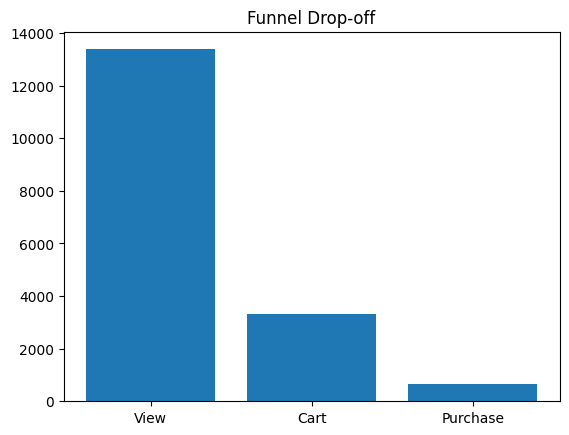

In [6]:
import matplotlib.pyplot as plt

funnel = ['View', 'Cart', 'Purchase']
values = [view_users, cart_users, purchase_users]

plt.bar(funnel, values)
plt.title("Funnel Drop-off")
plt.show()